In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## configuation settings

In [8]:
# settings
N = 20    # neurons
K = 3     # motifs states (e.g., A, B, C)
M = 50    # samples
S = 2     # max active at once (constraint)
FILENAME = "simNeural"

## generative model 
poisson distribution data of the output (Y) variable

In [9]:
def generate_and_save_data():
    np.random.seed(42) # reproducibility

    # initialize basis patterns (the fixed composition of a neuron in each motif)
    Lambdas = np.random.uniform(0, 20, size=(N, K))

    # pre-allocate
    Alphas = np.zeros((K, M)) # "States" (mixing weights)
    Y = np.zeros((N, M))      # observed data (Spikes)

    print("Generating data...")
    for i in range(M):
        # 1. sparsity: pick active motifs
        active_indices = np.random.choice(np.arange(K), size=S, replace=False)

        # 2. mixing: Assign weights
        weights = np.zeros(K)
        weights[active_indices] = np.random.uniform(0.2, 1.0, size=S)
        if np.sum(weights) > 0: weights /= np.sum(weights) # normalize

        Alphas[:, i] = weights

        # 3. observation: Poisson process
        expected_rates = np.dot(Lambdas, weights)
        Y[:, i] = np.random.poisson(expected_rates)

    # 1. save as compressed numpy
    np.savez(f"{FILENAME}.npz", Y=Y, Alphas=Alphas, Lambdas=Lambdas)

    # 2. save observed spikes Y to CSV
    # Rows = Neurons, Cols = Time Steps
    df_y = pd.DataFrame(Y, index=[f"Neuron_{n}" for n in range(N)],
                        columns=[f"Time_{t}" for t in range(M)])
    df_y.to_csv(f"{FILENAME}.csv")

    print(f"Success! Data saved to '{FILENAME}.npz' and '{FILENAME}.csv'")

## load data

In [10]:
def load_and_inspect():
    print("\n--- INSPECTING DATA ---")

    df = pd.read_csv(f"{FILENAME}.csv", index_col=0)

    print("First 5 Time Steps of Neural Data (Rows=Neurons, Cols=Time):")
    print(df.iloc[:, :5])
    print(f"\nShape of Data: {df.shape} (Neurons x Samples)")

    return df

In [ ]:
def plot_spike_lines(df):
    plt.figure(figsize=(12, 6))

    # first 5 neurons plot to keep it readable
    neurons_to_plot = 5

# --- EXECUTE STEPS ---
generate_and_save_data()     # Step 1: Create & Save
df_data = load_and_inspect() # Step 2: Load & View DataFrame

Generating data...
Success! Data saved to 'simNeural.npz' and 'simNeural.csv'

--- INSPECTING DATA ---
First 5 Time Steps of Neural Data (Rows=Neurons, Cols=Time):
           Time_0  Time_1  Time_2  Time_3  Time_4
Neuron_0     14.0    11.0    10.0    19.0    15.0
Neuron_1      1.0     8.0     8.0    12.0     9.0
Neuron_2     14.0     9.0     6.0     8.0     3.0
Neuron_3     10.0    20.0    10.0     9.0     1.0
Neuron_4      3.0    13.0     9.0    13.0    11.0
Neuron_5      9.0    14.0     3.0     7.0     4.0
Neuron_6      9.0     7.0     6.0    13.0     6.0
Neuron_7      8.0     9.0     2.0     6.0     4.0
Neuron_8     10.0     9.0     8.0    10.0    17.0
Neuron_9      6.0     3.0    12.0    11.0    12.0
Neuron_10     1.0     7.0     7.0    12.0     7.0
Neuron_11    16.0    15.0    12.0    18.0    22.0
Neuron_12     6.0     8.0     3.0     5.0     3.0
Neuron_13     4.0     9.0     8.0     6.0     3.0
Neuron_14     9.0     3.0     3.0     9.0    13.0
Neuron_15     7.0    12.0    13.0   

## plots view

In [15]:
datefile = "simNeural.npz"

Loaded data from simNeural.npz


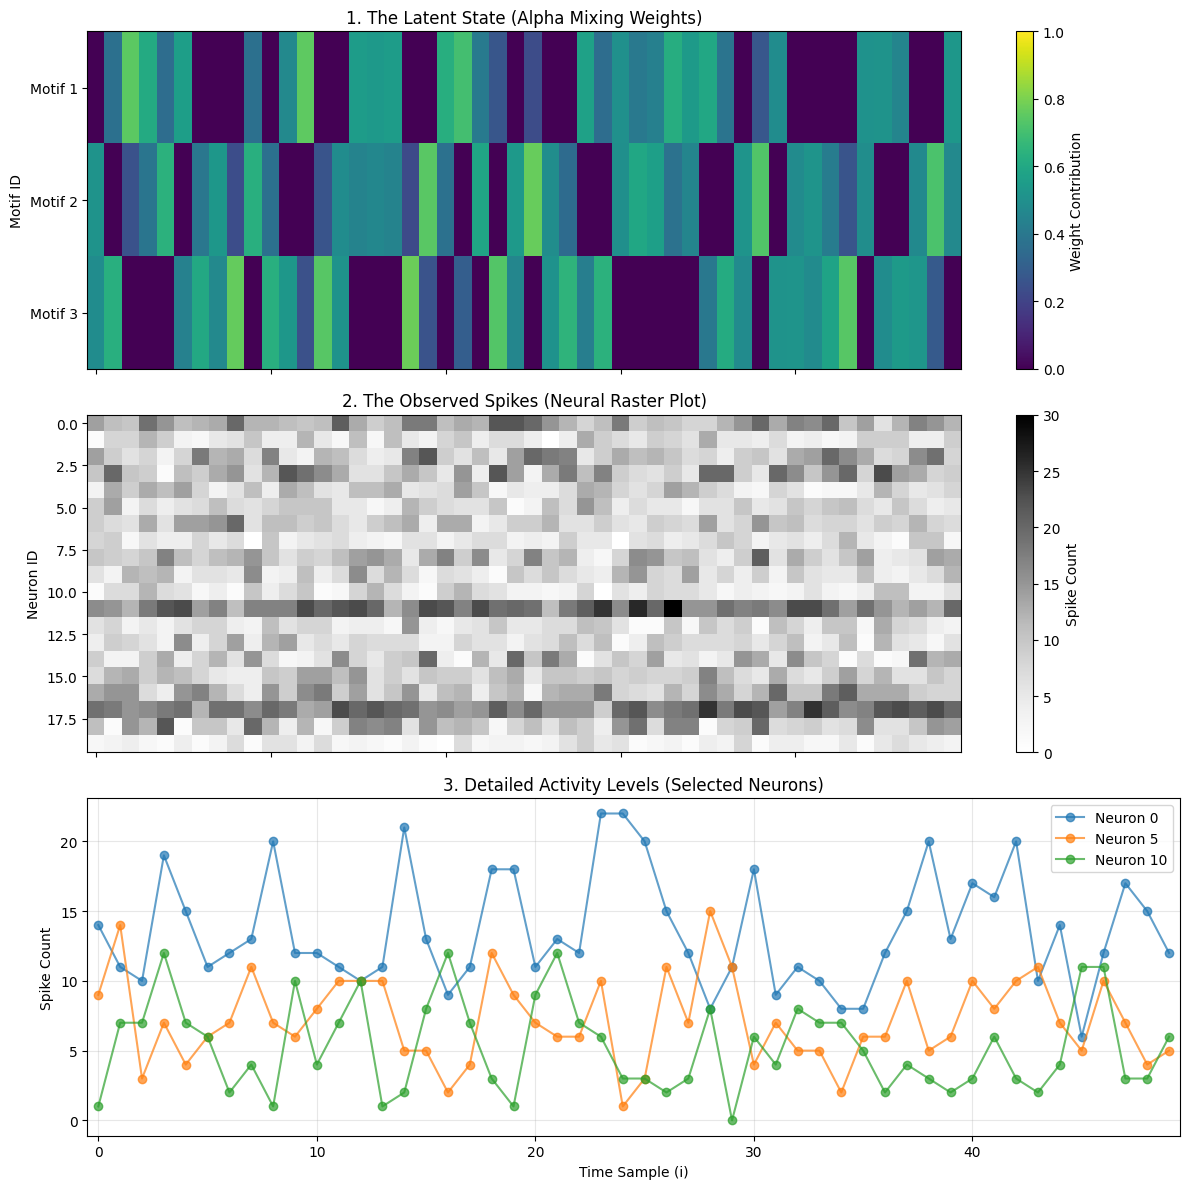

In [16]:
def visualize_dashboard():
    try:
        data = np.load(datefile)
        Y = data['Y']
        Alphas = data['Alphas'] # shape: (Motifs, Time)
        print(f"Loaded data from {datefile}")
    except FileNotFoundError:
        print("Error: Data file not found. Run the generation script first!")
        return

    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

    # --- PLOT 1: Latent Mixing Weights (Heatmap) ---
    # This shows the "Recipe" changing over time
    im1 = axes[0].imshow(Alphas, aspect='auto', cmap='viridis', interpolation='nearest', vmin=0, vmax=1)
    axes[0].set_ylabel("Motif ID")
    axes[0].set_yticks(np.arange(Alphas.shape[0]))
    axes[0].set_yticklabels([f"Motif {k+1}" for k in range(Alphas.shape[0])])
    axes[0].set_title("1. The Latent State (Alpha Mixing Weights)")
    plt.colorbar(im1, ax=axes[0], label="Weight Contribution")

    # --- PLOT 2: Spike Raster Plot (Heatmap) ---
    # shows ALL neurons firing at once (Black = Spikes)
    im2 = axes[1].imshow(Y, aspect='auto', cmap='Greys', interpolation='nearest')
    axes[1].set_ylabel("Neuron ID")
    axes[1].set_title("2. The Observed Spikes (Neural Raster Plot)")
    plt.colorbar(im2, ax=axes[1], label="Spike Count")

    # --- PLOT 3: Individual Neuron Traces (Line Plot) ---
    # shows the intensity levels for just the first 3 neurons
    time_steps = np.arange(Y.shape[1])
    neurons_to_plot = [0, 5, 10] # Let's look at Neuron 0, 5, and 10

    for n_idx in neurons_to_plot:
        # check if we actually have this many neurons
        if n_idx < Y.shape[0]:
            axes[2].plot(time_steps, Y[n_idx, :], marker='o', alpha=0.7, label=f"Neuron {n_idx}")

    axes[2].set_ylabel("Spike Count")
    axes[2].set_xlabel("Time Sample (i)")
    axes[2].set_title("3. Detailed Activity Levels (Selected Neurons)")
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)

    # final Layout
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_dashboard()